In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd


In [41]:
import os

os.listdir("/kaggle/input/nslkdd")

['KDDTest+.arff',
 'KDDTest-21.arff',
 'KDDTest1.jpg',
 'KDDTrain+.txt',
 'KDDTrain+_20Percent.txt',
 'KDDTest-21.txt',
 'KDDTest+.txt',
 'KDDTrain+.arff',
 'index.html',
 'nsl-kdd',
 'KDDTrain+_20Percent.arff',
 'KDDTrain1.jpg']

In [42]:
import pandas as pd

train = pd.read_csv("/kaggle/input/nslkdd/KDDTrain+.txt", header=None)
test = pd.read_csv("/kaggle/input/nslkdd/KDDTest+.txt", header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [43]:
train.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42],
      dtype='int64')

In [44]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [45]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
           "land","wrong_fragment","urgent","hot","num_failed_logins",
           "logged_in","num_compromised","root_shell","su_attempted",
           "num_root","num_file_creations","num_shells","num_access_files",
           "num_outbound_cmds","is_host_login","is_guest_login",
           "count","srv_count","serror_rate","srv_serror_rate",
           "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
           "dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate",
           "label","difficulty"]

train.columns = columns
test.columns = columns

In [46]:
train.drop("difficulty",axis=1,inplace=True)
test.drop("difficulty",axis=1,inplace=True)

In [47]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [48]:
train["label"].value_counts().head()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931


In [49]:
train["label"] = train["label"].apply(lambda x:0 if x=="normal" else 1)
test["label"] = test["label"].apply(lambda x:0 if x=="normal" else 1)

In [50]:
train["label"].value_counts()

,count
label,
0,67343
1,58630


In [51]:
cat_cols = ["protocol_type","service","flag"]

In [52]:
train = pd.get_dummies(train,columns=cat_cols)
test = pd.get_dummies(test,columns=cat_cols)

In [53]:
test = test.reindex(columns=train.columns,fill_value=0)

In [54]:
X_train = train.drop("label",axis=1)
y_train = train["label"]

X_test = test.drop("label",axis=1)
y_test = test["label"]

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_preds = lr.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,lr_preds))

Logistic Regression Accuracy: 0.7538147622427254


In [57]:
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.65      0.93      0.76      9711
           1       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



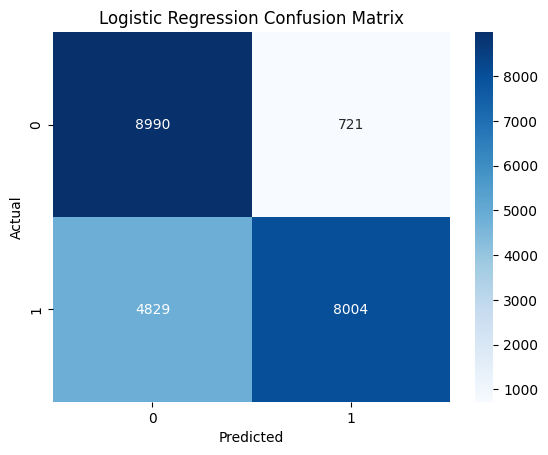

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.7647711142654364


In [60]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



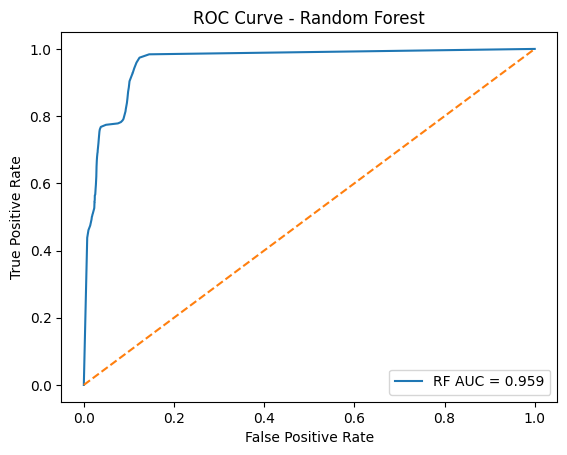

In [61]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="RF AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    sub_sample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [63]:
xgb.fit(X_train,y_train)
xgb_preds = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:28:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "sub_sample", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [64]:
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 0.7883694109297374

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



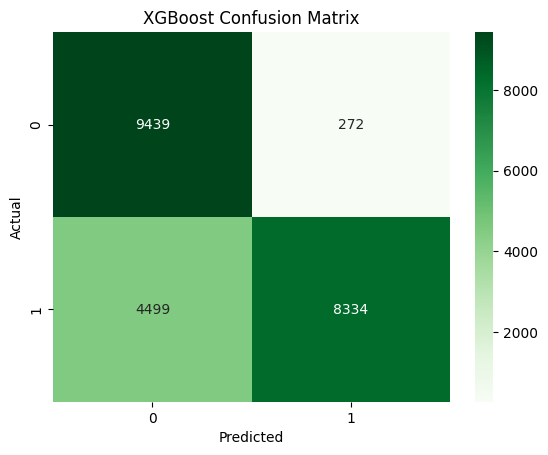

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

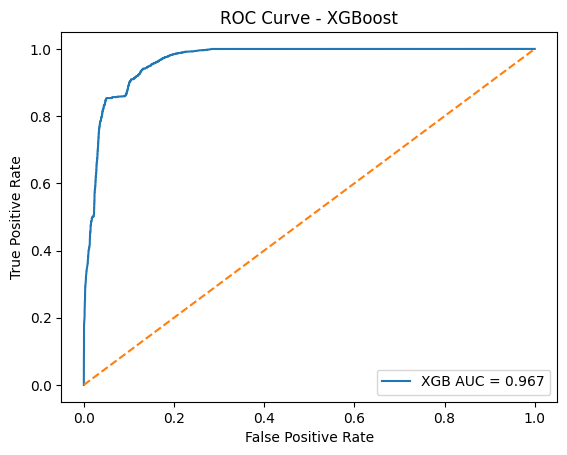

In [66]:
from sklearn.metrics import roc_curve, auc

xgb_probs = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="XGB AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#Multi-class Intrusion Detection

In [75]:
train = pd.read_csv("/kaggle/input/nslkdd/KDDTrain+.txt", header=None)
test = pd.read_csv("/kaggle/input/nslkdd/KDDTest+.txt", header=None)

In [76]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
           "land","wrong_fragment","urgent","hot","num_failed_logins",
           "logged_in","num_compromised","root_shell","su_attempted",
           "num_root","num_file_creations","num_shells","num_access_files",
           "num_outbound_cmds","is_host_login","is_guest_login",
           "count","srv_count","serror_rate","srv_serror_rate",
           "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
           "dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate",
           "label","difficulty"]

train.columns = columns
test.columns = columns

In [77]:
train.columns = columns
test.columns = columns

train.drop("difficulty", axis=1, inplace=True)
test.drop("difficulty", axis=1, inplace=True)

In [78]:
dos_attacks = ['neptune','smurf','back','teardrop','pod','land']
probe_attacks = ['ipsweep','nmap','portsweep','satan']
r2l_attacks = ['ftp_write','guess_passwd','imap','phf','multihop','warezclient','warezmaster']
u2r_attacks = ['buffer_overflow','loadmodule','perl','rootkit']

In [79]:
def attack_category(label):
    if label == 'normal':
        return 'normal'
    elif label in dos_attacks:
        return 'dos'
    elif label in probe_attacks:
        return 'probe'
    elif label in r2l_attacks:
        return 'r2l'
    elif label in u2r_attacks:
        return 'u2r'
    else:
        return 'other'

train['attack_type'] = train['label'].apply(attack_category)
test['attack_type'] = test['label'].apply(attack_category)

In [80]:
train['attack_type'].value_counts()

,count
attack_type,
normal,67343
dos,45927
probe,11656
r2l,993
u2r,52
other,2


In [81]:
train.drop(['label'], axis=1, inplace=True)
test.drop(['label'], axis=1, inplace=True)

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['attack_type'] = le.fit_transform(train['attack_type'])
test['attack_type'] = le.transform(test['attack_type'])

print(le.classes_)

['dos' 'normal' 'other' 'probe' 'r2l' 'u2r']


In [83]:
cat_cols = ["protocol_type","service","flag"]

train = pd.get_dummies(train, columns=cat_cols)
test = pd.get_dummies(test, columns=cat_cols)

test = test.reindex(columns=train.columns, fill_value=0)

In [85]:
X_train = train.drop("attack_type", axis=1)
y_train = train["attack_type"]

X_test = test.drop("attack_type", axis=1)
y_test = test["attack_type"]

In [86]:
X_train = train.drop("attack_type", axis=1)
y_train = train["attack_type"]

X_test = test.drop("attack_type", axis=1)
y_test = test["attack_type"]

In [87]:
from xgboost import XGBClassifier

xgb_multi = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_multi.fit(X_train, y_train)

multi_preds = xgb_multi.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, classification_report

print("Multi-Class Accuracy:", accuracy_score(y_test, multi_preds))
print(classification_report(y_test, multi_preds, target_names=le.classes_))

Multi-Class Accuracy: 0.7312810503903477
              precision    recall  f1-score   support

         dos       0.87      0.99      0.93      5741
      normal       0.68      0.97      0.80      9711
       other       0.00      0.00      0.00      3750
       probe       0.56      1.00      0.72      1106
         r2l       0.97      0.11      0.19      2199
         u2r       0.31      0.11      0.16        37

    accuracy                           0.73     22544
   macro avg       0.57      0.53      0.47     22544
weighted avg       0.64      0.73      0.64     22544



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
